# LAS CMS — Phase 2: Exploratory Data Analysis
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings, json

warnings.filterwarnings('ignore')

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

COLORS = {
    'primary':'#1B4F72', 'secondary':'#2E86C1', 'accent':'#17A589',
    'warning':'#E74C3C', 'success':'#27AE60', 'neutral':'#95A5A6', 'bg':'#FAFBFC',
}
PALETTE = ['#1B4F72','#2E86C1','#17A589','#E67E22','#8E44AD',
           '#E74C3C','#27AE60','#F39C12','#3498DB','#1ABC9C']

plt.rcParams.update({
    'figure.facecolor':COLORS['bg'], 'axes.facecolor':'#FFFFFF',
    'font.family':'sans-serif', 'font.size':11,
    'axes.titlesize':14, 'axes.titleweight':'bold',
    'axes.grid':True, 'grid.alpha':0.3,
    'axes.spines.top':False, 'axes.spines.right':False,
})

findings = []
chart_count = 0

def save_chart(fig, name):
    global chart_count; chart_count += 1
    fp = OUTPUT_DIR / f"chart_{chart_count:02d}_{name}.png"
    fig.savefig(fp, dpi=150, bbox_inches='tight', facecolor=COLORS['bg']); print(f"  ✓ {fp.name}"); return fp

def add_finding(cat, msg, sev="INFO"):
    findings.append({'category':cat, 'finding':msg, 'severity':sev})

print("✓ Setup complete")

✓ Setup complete


## Load Data

In [2]:
TABLE_COLUMNS = {
    "programs": ["id","programName","caseReferred","caseReferredsub","caseReferedsubtext","districtName","zakatEligible","interviewDate","interviewerName","clientName","partyName","complainantName","relationShip","fatherHusbandName","contactNumber","alternativecontactNumber","cnic","gender","age","religion","religionOther","caseFacts","caseSubmittedFAppro","caseApprovalStatus","approvalDate","case_not_filed","case_not_filed_reason","vakalatnamaSubmissionDate","caseFileDate","lawyer1","lawyer2","reasonOfChange","courtName","levelOfCourt","caseNumber","firNumber","policeStation","natureOfCase","typeOfCase","mainCaseCategory","sgbvSubCat","caseFiledUnderAct","caseFiledOther","nextHearing","currentCaseStatus","caseDecision","caseDisposalDate","ctcStatus","caseStage","caseStageother","additionalComment","created_at","updated_at","username","edited_by","primarykey","rejectionReason","UniqueNumber","uniqueYear","UniqueNumber2"],
    "hearings": ["id","programsID","caseNumber","primarykey","date","nextHearing","hearingUpdate","updated_at","created_at"],
    "programs_detail": ["id","programsid","programName","caseReferred","caseReferredsub","caseReferedsubtext","districtName","zakatEligible","interviewDate","interviewerName","clientName","complainantName","relationShip","fatherHusbandName","contactNumber","alternativecontactNumber","cnic","gender","age","religion","religionOther","caseFacts","caseSubmittedFAppro","caseApprovalStatus","approvalDate","case_not_filed","case_not_filed_reason","vakalatnamaSubmissionDate","caseFileDate","lawyer1","lawyer2","reasonOfChange","courtName","levelOfCourt","caseNumber","firNumber","policeStation","natureOfCase","typeOfCase","mainCaseCategory","sgbvSubCat","caseFiledUnderAct","caseFiledOther","nextHearing","currentCaseStatus","caseDecision","caseDisposalDate","ctcStatus","caseStage","caseStageother","additionalComment","created_at","updated_at","username","edited_by","primarykey","rejectionReason","UniqueNumber","uniqueYear","UniqueNumber2"],
    "users": ["id","google_id","name","email","google_email","google_avatar","provider","provider_token","provider_refresh_token","provider_token_expires_at","email_verified_at","password","remember_token","created_at","updated_at","created_by","allowed_programs","user_type","roles","last_login_at","last_login_ip"],
    "case_documents": ["id","program_id","uploaded_by","file_name","file_path","created_at","updated_at"],
    "court": ["id","name","court_long","district_id","districtName","address","is_active","created_by","created_on","last_modified_by","last_modified_on","is_deleted","deleted_by","deleted_on","last_status_modified_on"],
    "interviews": ["id","created_by","status","created_at","updated_at"],
}

In [3]:
def load_table(name, data_dir):
    """Load table from TSV/CSV and assign correct column names."""
    from pathlib import Path
    
    schema_cols = TABLE_COLUMNS.get(name)
    df = pd.DataFrame()
    source = ""
    
    for ext, sep in [('.tsv', '\t'), ('.csv', '\t'), ('.csv', ',')]:
        fpath = data_dir / f"{name}{ext}"
        if not fpath.exists():
            continue
        try:
            # Read without header first to check
            test = pd.read_csv(fpath, sep=sep, nrows=2, header=None, on_bad_lines='skip')
            if test.empty or len(test.columns) < 3:
                continue
            
            # Read full file without header
            df = pd.read_csv(fpath, sep=sep, header=None, on_bad_lines='warn',
                            low_memory=False, na_values=['NULL','null','None',''])
            
            # Check if first row looks like a header (matches schema column names)
            first_row = [str(v).strip() for v in df.iloc[0].values[:5]]
            if schema_cols and first_row[0] == schema_cols[0]:
                # File HAS a header row — drop it, it's the column names
                df = df.iloc[1:].reset_index(drop=True)
            
            # Assign column names from schema
            if schema_cols:
                if len(df.columns) == len(schema_cols):
                    df.columns = schema_cols
                elif len(df.columns) > len(schema_cols):
                    df.columns = schema_cols + [f'extra_{i}' for i in range(len(df.columns) - len(schema_cols))]
                else:
                    df.columns = schema_cols[:len(df.columns)]
            
            source = f"{ext[1:]}→{len(df.columns)}cols"
            break
        except Exception as e:
            continue
    
    if df.empty:
        print(f"  ⚠ {name} — not found or empty")
        return pd.DataFrame()
    
    # Clean special values
    df = df.replace(['NULL','null','None','0000-00-00','0000-00-00 00:00:00'], pd.NA)
    
    print(f"  ✓ {name:30s} {len(df):>6,} rows × {len(df.columns):>2} cols  [{source}]")
    return df

In [4]:
print("Loading tables...\n")

programs        = load_table("programs", DATA_DIR)
hearings        = load_table("hearings", DATA_DIR)
programs_detail = load_table("programs_detail", DATA_DIR)
users           = load_table("users", DATA_DIR)
case_documents  = load_table("case_documents", DATA_DIR)
court           = load_table("court", DATA_DIR)
interviews      = load_table("interviews", DATA_DIR)

if programs.empty:
    raise FileNotFoundError("programs not loaded!")

print(f"\n✓ programs: {len(programs):,} rows × {len(programs.columns)} columns")

Loading tables...

  ✓ programs                        3,886 rows × 60 cols  [tsv→60cols]
  ✓ hearings                       13,740 rows ×  9 cols  [tsv→9cols]
  ✓ programs_detail                 6,362 rows × 60 cols  [tsv→60cols]
  ✓ users                              89 rows × 21 cols  [tsv→21cols]
  ✓ case_documents                    774 rows ×  7 cols  [tsv→7cols]
  ✓ court                           1,457 rows × 15 cols  [tsv→15cols]
  ✓ interviews                        131 rows ×  5 cols  [tsv→5cols]

✓ programs: 3,886 rows × 60 columns


## Verify Columns

In [5]:
print("Key columns check:\n")
key = ['id','programName','districtName','gender','caseDecision','natureOfCase',
       'caseFacts','cnic','clientName','lawyer1','levelOfCourt','currentCaseStatus',
       'interviewDate','caseFileDate','contactNumber','fatherHusbandName','age']

for c in key:
    if c in programs.columns:
        sample = programs[c].dropna().head(1).values
        s = str(sample[0])[:50] if len(sample) > 0 else "all null"
        print(f"  ✓ {c:30s} | {programs[c].notna().sum():>5,} filled | e.g. {s}")
    else:
        print(f"  ✗ {c:30s} | MISSING")

print(f"\n  Found {sum(1 for c in key if c in programs.columns)}/{len(key)} key columns")

if 'hearingUpdate' in hearings.columns:
    print(f"\n  ✓ hearings.hearingUpdate (notes): {hearings['hearingUpdate'].notna().sum():,} filled")
elif not hearings.empty:
    print(f"\n  Hearings columns: {hearings.columns.tolist()}")

Key columns check:

  ✓ id                             | 3,880 filled | e.g. 1
  ✓ programName                    | 3,615 filled | e.g. IG
  ✓ districtName                   | 3,162 filled | e.g. Karachi Central
  ✓ gender                         | 3,553 filled | e.g. Female
  ✓ caseDecision                   | 2,359 filled | e.g. In Progress
  ✓ natureOfCase                   | 2,765 filled | e.g. Civil
  ✓ caseFacts                      | 2,938 filled | e.g. Family Execution
  ✓ cnic                           | 2,973 filled | e.g. 44201-8494117-6
  ✓ clientName                     | 3,165 filled | e.g. Muslima
  ✓ lawyer1                        | 2,821 filled | e.g. Barkat Ali
  ✓ levelOfCourt                   | 2,452 filled | e.g. civil judge/ senior civil judge
  ✓ currentCaseStatus              | 2,459 filled | e.g. Pending
  ✓ interviewDate                  | 3,486 filled | e.g. 2021-03-04
  ✓ caseFileDate                   | 2,350 filled | e.g. 2021-07-05
  ✓ contactNumber     

---
## Batch 1: Case Overview

### 1.1 Case Decision

  ✓ chart_01_case_decisions.png


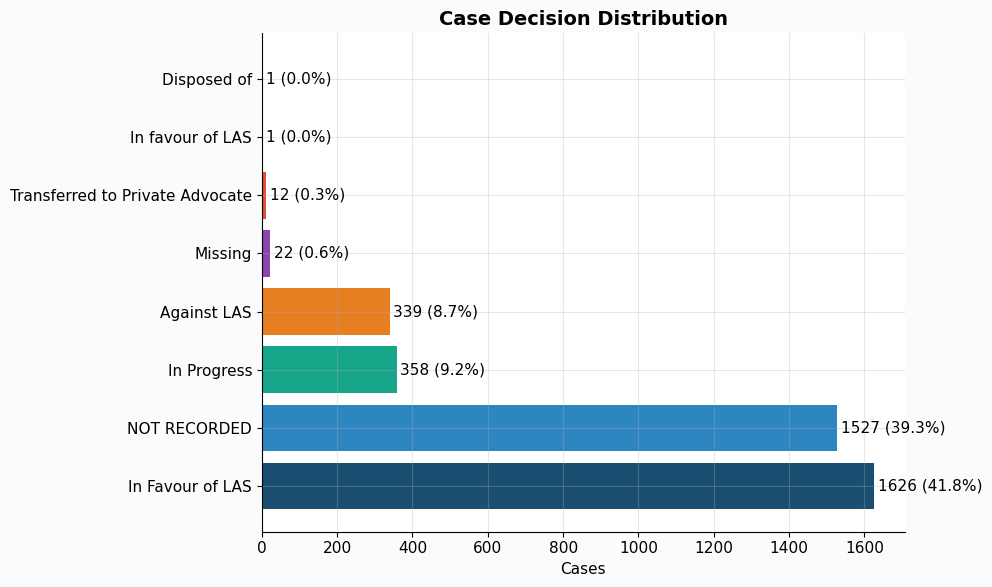


Missing: 39.3%


In [6]:
if 'caseDecision' in programs.columns:
    dec = programs['caseDecision'].fillna('NOT RECORDED').value_counts()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(dec.index, dec.values, color=PALETTE[:len(dec)])
    ax.set_xlabel('Cases'); ax.set_title('Case Decision Distribution')
    for bar, val in zip(ax.patches, dec.values):
        ax.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2, f'{val} ({val/len(programs)*100:.1f}%)', va='center')
    plt.tight_layout(); save_chart(fig, "case_decisions"); plt.show()
    
    miss = programs['caseDecision'].isna().sum()/len(programs)*100
    add_finding("Outcomes", f"{miss:.1f}% missing decisions", "CRITICAL" if miss>10 else "MODERATE")
    print(f"\nMissing: {miss:.1f}%")
else:
    print("⚠ caseDecision not found")

### 1.2 Case Status

  ✓ chart_02_case_status.png


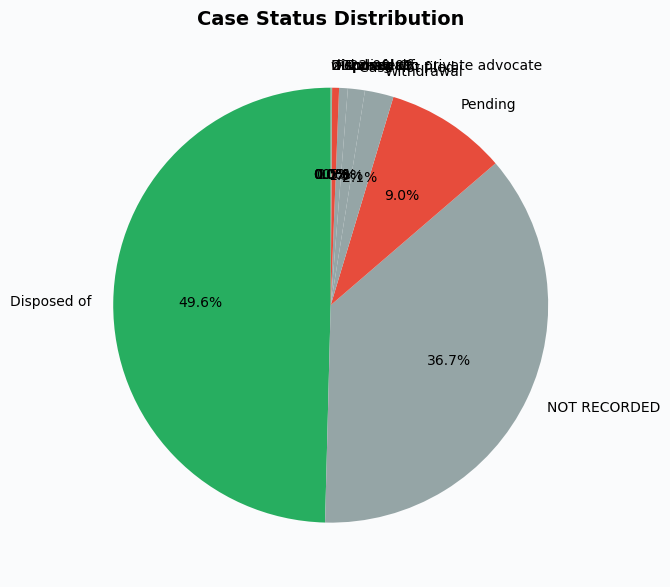

  Disposed of: 1,927
  NOT RECORDED: 1,427
  Pending: 351
  Withdrawal: 83
  Case not filed: 49
  Transfer to private advocate: 25
  Pending : 20
  disposed of: 1
  2022-08-09: 1
  Disposed Of: 1
  withdrawal: 1


In [7]:
if 'currentCaseStatus' in programs.columns:
    st = programs['currentCaseStatus'].fillna('NOT RECORDED').value_counts()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    cols = [COLORS['success'] if 'Disposed' in str(s) else COLORS['warning'] if 'Pending' in str(s) else COLORS['neutral'] for s in st.index]
    ax.pie(st.values, labels=st.index, autopct='%1.1f%%', colors=cols, startangle=90, textprops={'fontsize':10})
    ax.set_title('Case Status Distribution')
    plt.tight_layout(); save_chart(fig, "case_status"); plt.show()
    for s,c in st.items(): print(f"  {s}: {c:,}")
else:
    print("⚠ currentCaseStatus not found")

### 1.3 Cases by Year

Using: interviewDate
  ✓ chart_03_cases_by_year.png


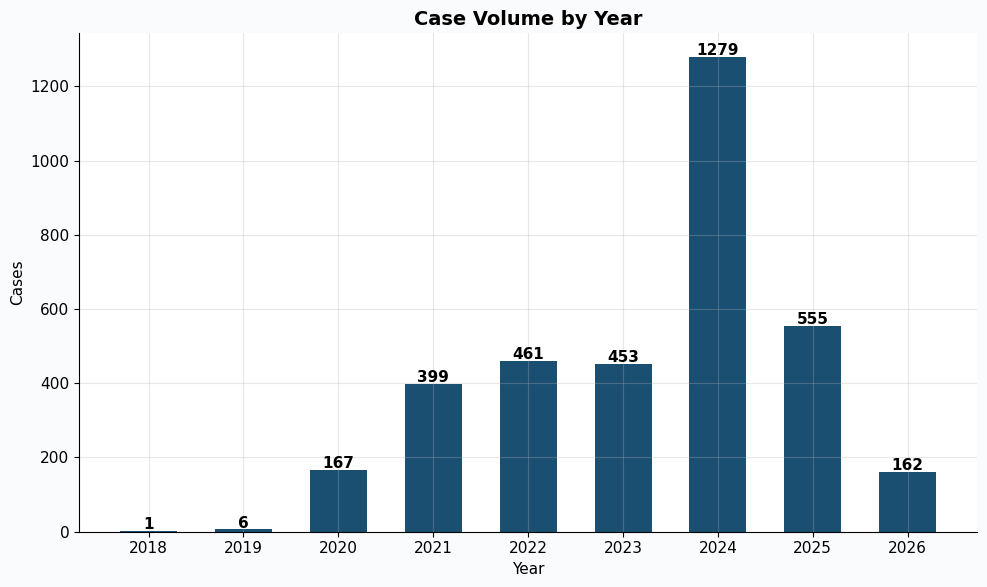

In [8]:
date_col = None
for c in ['interviewDate','caseFileDate','created_at']:
    if c in programs.columns: date_col = c; break

if date_col:
    print(f"Using: {date_col}")
    programs['_date'] = pd.to_datetime(programs[date_col], errors='coerce')
    programs['_year'] = programs['_date'].dt.year
    yr = programs['_year'].dropna().astype(int).value_counts().sort_index()
    yr = yr[(yr.index>=2018)&(yr.index<=2026)]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(yr.index.astype(str), yr.values, color=COLORS['primary'], width=0.6)
    ax.set_xlabel('Year'); ax.set_ylabel('Cases'); ax.set_title('Case Volume by Year')
    for b,v in zip(bars, yr.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v), ha='center', fontweight='bold')
    plt.tight_layout(); save_chart(fig, "cases_by_year"); plt.show()
    add_finding("Volume", f"Yearly: {yr.to_dict()}", "INFO")
else:
    print("⚠ No date column")

### 1.4 Gender

  ✓ chart_04_gender.png


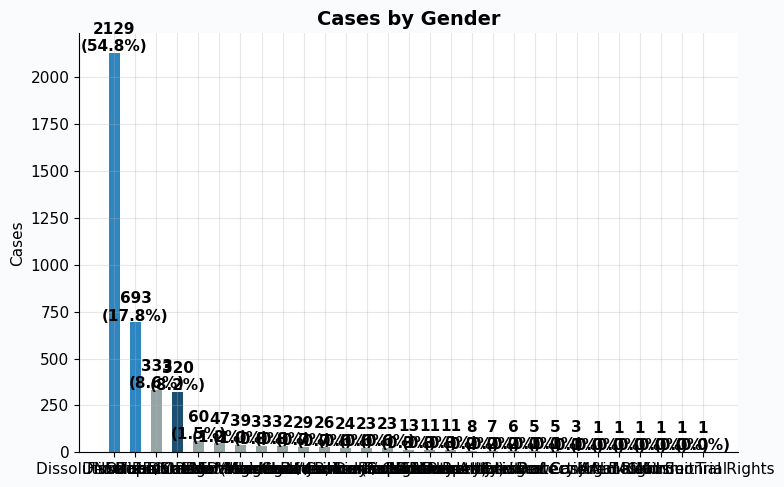

In [9]:
if 'gender' in programs.columns:
    gc = programs['gender'].fillna('NOT RECORDED').value_counts()
    
    fig, ax = plt.subplots(figsize=(8, 5))
    cols = [COLORS['secondary'] if 'emale' in str(g) else COLORS['primary'] if 'ale' in str(g) else COLORS['neutral'] for g in gc.index]
    ax.bar(gc.index, gc.values, color=cols, width=0.5)
    ax.set_ylabel('Cases'); ax.set_title('Cases by Gender')
    for i,(g,v) in enumerate(gc.items()):
        ax.text(i, v+10, f'{v}\n({v/len(programs)*100:.1f}%)', ha='center', fontweight='bold')
    plt.tight_layout(); save_chart(fig, "gender"); plt.show()
    
    fem = sum(v for g,v in gc.items() if 'emale' in str(g).lower())
    add_finding("Demographics", f"Female: {fem/len(programs)*100:.1f}%", "INFO")
else:
    print("⚠ gender not found")

### 1.5 Top 10 Districts

  ✓ chart_05_districts.png


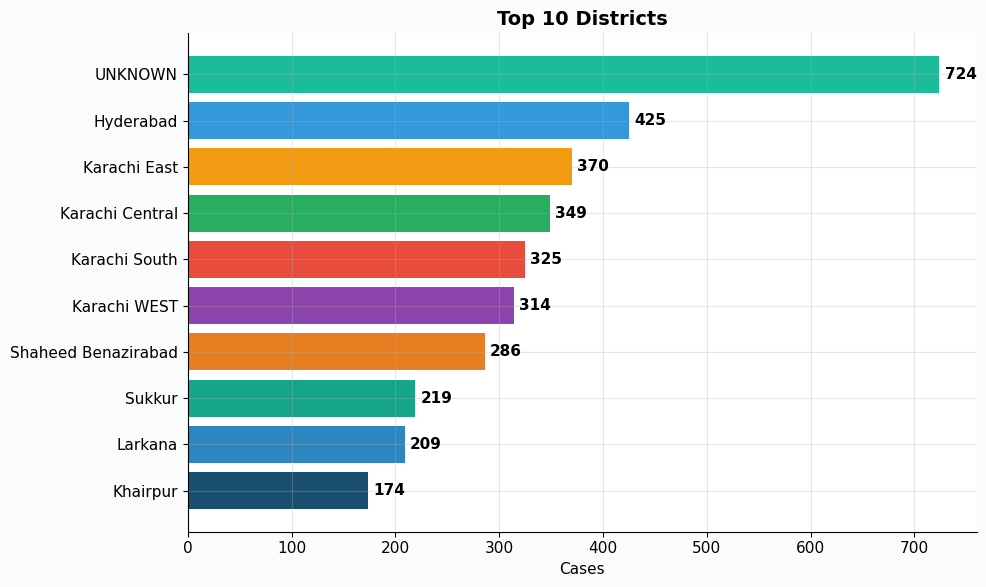

In [10]:
if 'districtName' in programs.columns:
    dc = programs['districtName'].fillna('UNKNOWN').value_counts().head(10)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(dc.index[::-1], dc.values[::-1], color=PALETTE[:len(dc)])
    ax.set_xlabel('Cases'); ax.set_title('Top 10 Districts')
    for b,v in zip(ax.patches, dc.values[::-1]):
        ax.text(b.get_width()+5, b.get_y()+b.get_height()/2, str(v), va='center', fontweight='bold')
    plt.tight_layout(); save_chart(fig, "districts"); plt.show()
else:
    print("⚠ districtName not found")

### 1.6 Nature of Case

  ✓ chart_06_nature_of_case.png


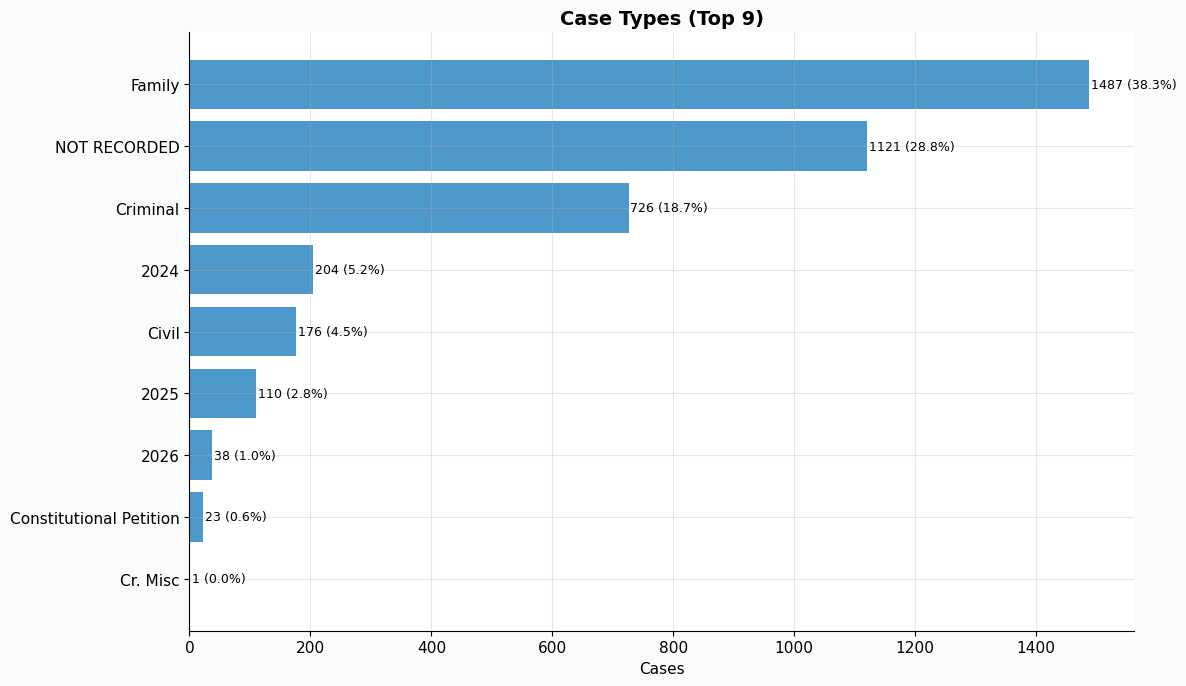

In [11]:
if 'natureOfCase' in programs.columns:
    nc = programs['natureOfCase'].fillna('NOT RECORDED').value_counts()
    data = nc.head(min(15, len(nc)))
    
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(data.index[::-1], data.values[::-1], color=COLORS['secondary'], alpha=0.85)
    ax.set_xlabel('Cases'); ax.set_title(f'Case Types (Top {len(data)})')
    for b,v in zip(ax.patches, data.values[::-1]):
        ax.text(b.get_width()+3, b.get_y()+b.get_height()/2, f'{v} ({v/len(programs)*100:.1f}%)', va='center', fontsize=9)
    plt.tight_layout(); save_chart(fig, "nature_of_case"); plt.show()
else:
    print("⚠ natureOfCase not found")

---
## Batch 2: Field Completeness

  ✓ chart_07_completeness.png


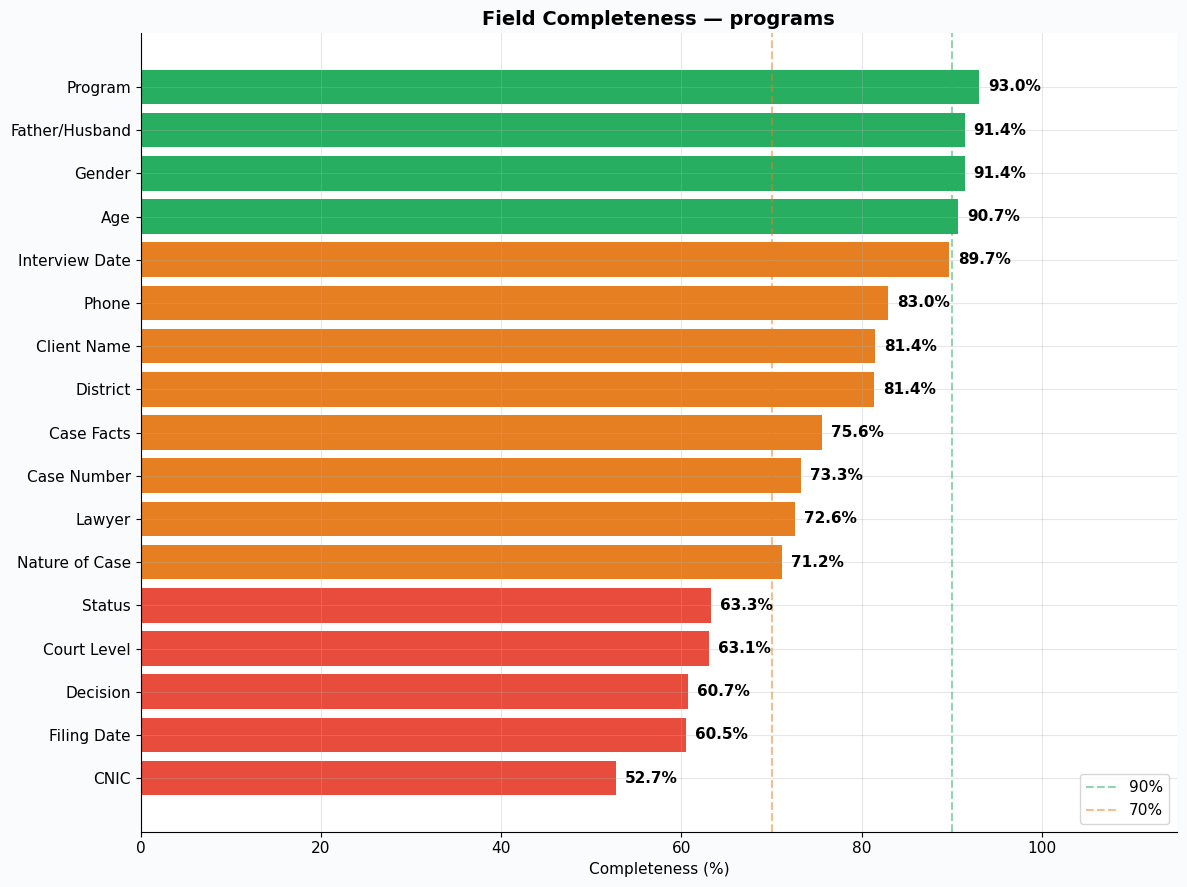


Score Card:
  🔴 CNIC                  52.7%  (2,048/3,886)
  🔴 Filing Date           60.5%  (2,350/3,886)
  🔴 Decision              60.7%  (2,359/3,886)
  🔴 Court Level           63.1%  (2,452/3,886)
  🔴 Status                63.3%  (2,459/3,886)
  🟡 Nature of Case        71.2%  (2,765/3,886)
  🟡 Lawyer                72.6%  (2,821/3,886)
  🟡 Case Number           73.3%  (2,847/3,886)
  🟡 Case Facts            75.6%  (2,938/3,886)
  🟡 District              81.4%  (3,162/3,886)
  🟡 Client Name           81.4%  (3,165/3,886)
  🟡 Phone                 83.0%  (3,224/3,886)
  🟡 Interview Date        89.7%  (3,486/3,886)
  🟢 Age                   90.7%  (3,525/3,886)
  🟢 Gender                91.4%  (3,553/3,886)
  🟢 Father/Husband        91.4%  (3,553/3,886)
  🟢 Program               93.0%  (3,615/3,886)


In [12]:
# NOTE: in this DB, lawyer is "lawyer1" not "lawyerName", court is "levelOfCourt" not "courtLevel"
key_fields = {
    'clientName':'Client Name', 'fatherHusbandName':'Father/Husband',
    'cnic':'CNIC', 'gender':'Gender', 'age':'Age',
    'contactNumber':'Phone', 'districtName':'District',
    'natureOfCase':'Nature of Case', 'caseFacts':'Case Facts',
    'caseDecision':'Decision', 'currentCaseStatus':'Status',
    'caseFileDate':'Filing Date', 'interviewDate':'Interview Date',
    'lawyer1':'Lawyer', 'levelOfCourt':'Court Level',
    'programName':'Program', 'caseNumber':'Case Number',
}

completeness_data = []
for field, label in key_fields.items():
    if field in programs.columns:
        total = len(programs)
        ne = programs[field].dropna()
        if ne.dtype == 'object':
            ne = ne[ne.astype(str).str.strip() != '']
            if field == 'cnic':
                ne = ne[~ne.astype(str).str.contains('00000-0000000-0', na=False)]
        pct = len(ne)/total*100
        completeness_data.append({'field':label, 'filled':len(ne), 'total':total, 'pct':pct,
                                   'status':'🟢' if pct>=90 else '🟡' if pct>=70 else '🔴'})

if completeness_data:
    cdf = pd.DataFrame(completeness_data).sort_values('pct', ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 9))
    clrs = [COLORS['success'] if r['pct']>=90 else '#E67E22' if r['pct']>=70 else '#E74C3C' for _,r in cdf.iterrows()]
    ax.barh(cdf['field'], cdf['pct'], color=clrs)
    ax.set_xlabel('Completeness (%)'); ax.set_title('Field Completeness — programs')
    ax.set_xlim(0, 115)
    ax.axvline(90, color=COLORS['success'], linestyle='--', alpha=0.5, label='90%')
    ax.axvline(70, color='#E67E22', linestyle='--', alpha=0.5, label='70%')
    for b, pct in zip(ax.patches, cdf['pct']):
        ax.text(b.get_width()+1, b.get_y()+b.get_height()/2, f'{pct:.1f}%', va='center', fontweight='bold')
    ax.legend(loc='lower right')
    plt.tight_layout(); save_chart(fig, "completeness"); plt.show()
    
    for _,r in cdf.iterrows():
        if r['pct']<70: add_finding("Completeness", f"{r['field']}: {r['pct']:.1f}%", "CRITICAL")
        elif r['pct']<90: add_finding("Completeness", f"{r['field']}: {r['pct']:.1f}%", "MODERATE")
    
    print("\nScore Card:")
    for _,r in cdf.iterrows():
        print(f"  {r['status']} {r['field']:20s} {r['pct']:5.1f}%  ({r['filled']:,}/{r['total']:,})")
else:
    print("⚠ No key fields matched! Check column names.")

### CNIC Integrity

  ✓ chart_08_cnic.png


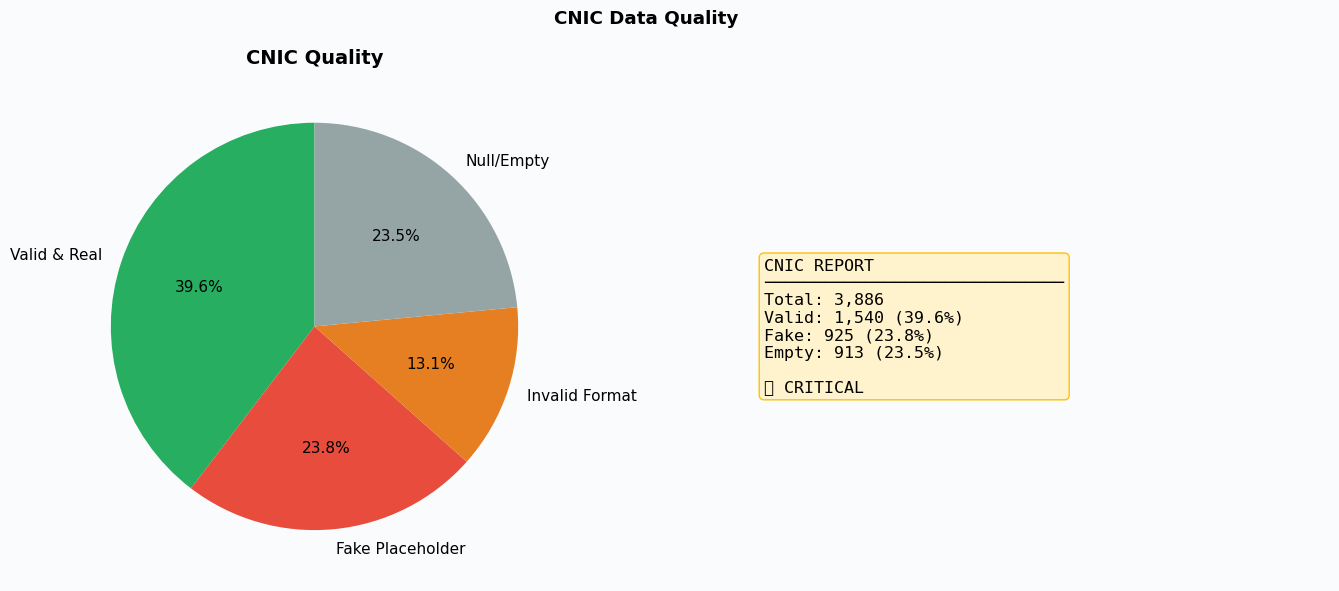

In [13]:
if 'cnic' in programs.columns:
    cd = programs['cnic'].fillna('').astype(str)
    total = len(cd)
    null_n = (cd=='').sum()
    fake_n = cd.str.contains('00000-0000000-0', na=False).sum()
    valid_fmt = cd.str.match(r'^\d{5}-\d{7}-\d{1}$', na=False)
    valid_real = (valid_fmt & ~cd.str.contains('00000-0000000-0')).sum()
    
    bk = {'Valid & Real':valid_real, 'Fake Placeholder':fake_n, 
          'Invalid Format':(~valid_fmt & (cd!='')).sum(), 'Null/Empty':null_n}
    
    fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.pie(bk.values(), labels=bk.keys(), autopct='%1.1f%%',
            colors=[COLORS['success'],COLORS['warning'],'#E67E22',COLORS['neutral']], startangle=90)
    ax1.set_title('CNIC Quality')
    ax2.axis('off')
    ax2.text(0.1, 0.5, f"CNIC REPORT\n{'─'*30}\nTotal: {total:,}\nValid: {valid_real:,} ({valid_real/total*100:.1f}%)\nFake: {fake_n:,} ({fake_n/total*100:.1f}%)\nEmpty: {null_n:,} ({null_n/total*100:.1f}%)\n\n🔴 CRITICAL",
            transform=ax2.transAxes, fontsize=12, va='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#FFF3CD', edgecolor='#FFC107'))
    fig.suptitle('CNIC Data Quality', fontweight='bold')
    plt.tight_layout(); save_chart(fig, "cnic"); plt.show()
    add_finding("CNIC", f"{fake_n} fake ({fake_n/total*100:.1f}%)", "CRITICAL")
else:
    print("⚠ cnic not found")

---
## Batch 3: Hearings

  ✓ chart_09_hearings_per_case.png


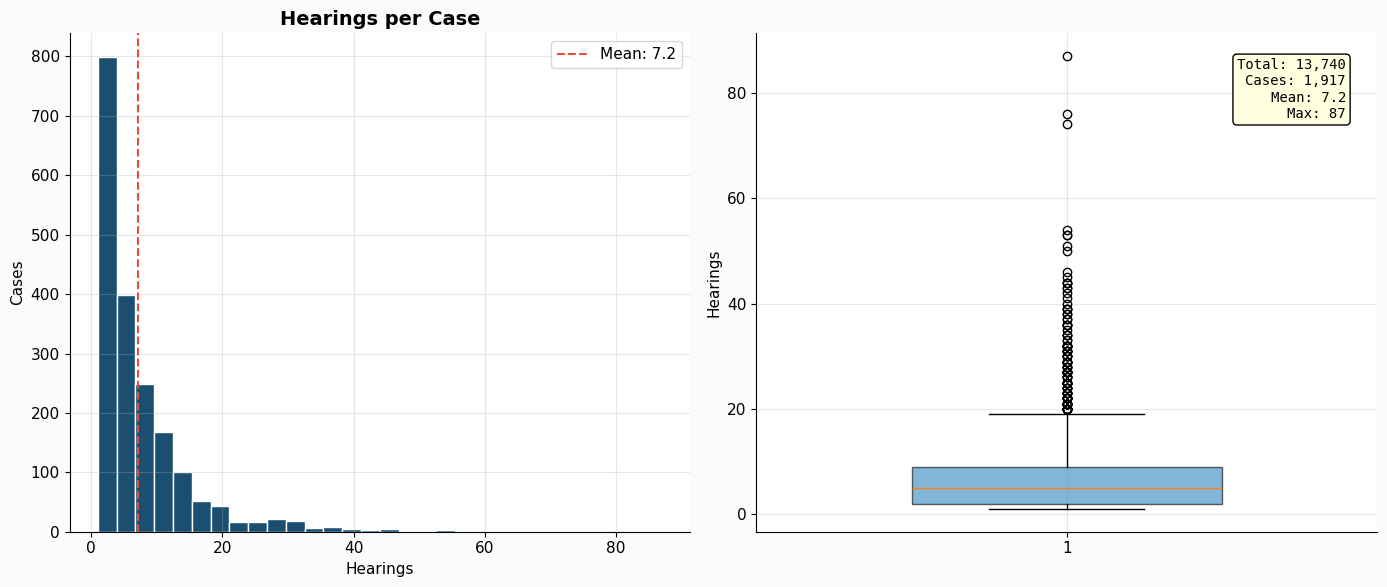

⚠ 51% cases with no hearings


In [14]:
if not hearings.empty and 'programsID' in hearings.columns:
    hpc = hearings['programsID'].value_counts()
    
    fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.hist(hpc.values, bins=30, color=COLORS['primary'], edgecolor='white')
    ax1.set_xlabel('Hearings'); ax1.set_ylabel('Cases'); ax1.set_title('Hearings per Case')
    ax1.axvline(hpc.mean(), color=COLORS['warning'], linestyle='--', label=f'Mean: {hpc.mean():.1f}')
    ax1.legend()
    
    ax2.boxplot(hpc.values, vert=True, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=COLORS['secondary'], alpha=0.6))
    ax2.set_ylabel('Hearings')
    ax2.text(0.95, 0.95, f"Total: {len(hearings):,}\nCases: {len(hpc):,}\nMean: {hpc.mean():.1f}\nMax: {hpc.max()}",
            transform=ax2.transAxes, fontsize=10, va='top', ha='right', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow'))
    plt.tight_layout(); save_chart(fig, "hearings_per_case"); plt.show()
    
    without = len(programs) - len(set(hearings['programsID'].unique()))
    pct_w = without/len(programs)*100
    add_finding("Hearings", f"{pct_w:.0f}% cases have ZERO hearings", "CRITICAL" if pct_w>30 else "MODERATE")
    print(f"⚠ {pct_w:.0f}% cases with no hearings")
else:
    print("⚠ Hearings not loaded or programsID missing")

### Hearing Notes Quality

  ✓ chart_10_hearing_notes.png


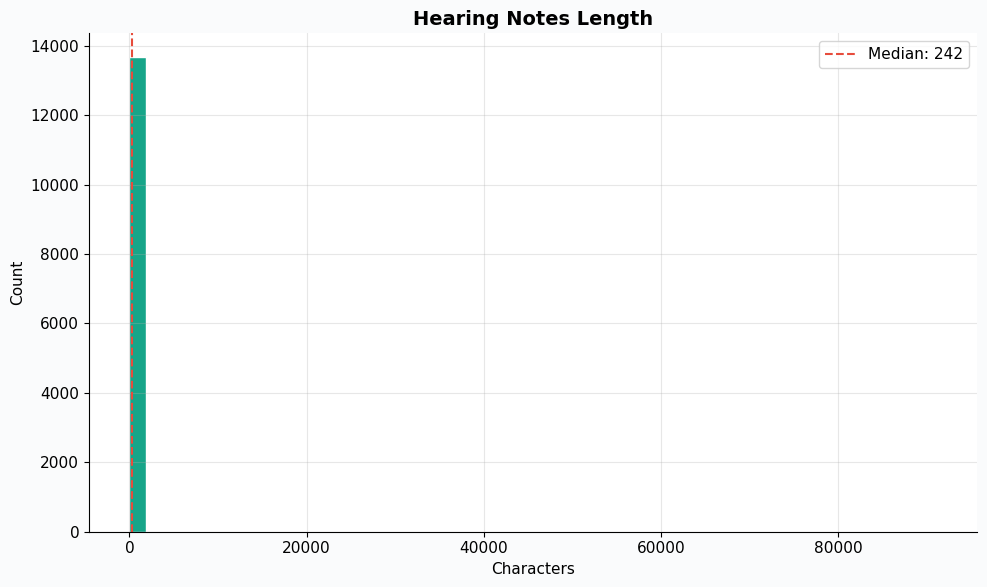

Empty: 64
NLP-ready (≥50 chars): 13,269 (97%)


In [15]:
# The notes column is "hearingUpdate" in this DB
if not hearings.empty and 'hearingUpdate' in hearings.columns:
    lengths = hearings['hearingUpdate'].fillna('').astype(str).str.len()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(lengths[lengths>0], bins=50, color=COLORS['accent'], edgecolor='white')
    ax.set_xlabel('Characters'); ax.set_ylabel('Count'); ax.set_title('Hearing Notes Length')
    med = lengths[lengths>0].median()
    ax.axvline(med, color=COLORS['warning'], linestyle='--', label=f'Median: {med:.0f}')
    ax.legend(); plt.tight_layout(); save_chart(fig, "hearing_notes"); plt.show()
    
    nlp = (lengths >= 50).sum()
    print(f"Empty: {(lengths==0).sum():,}")
    print(f"NLP-ready (≥50 chars): {nlp:,} ({nlp/len(hearings)*100:.0f}%)")
    add_finding("Hearings", f"Notes NLP-ready: {nlp/len(hearings)*100:.0f}%", "INFO")
else:
    print("⚠ hearingUpdate not found")

---
## Batch 4: Lawyers & Courts

### 4.1 Lawyer Case Load

  ✓ chart_11_lawyer_caseload.png


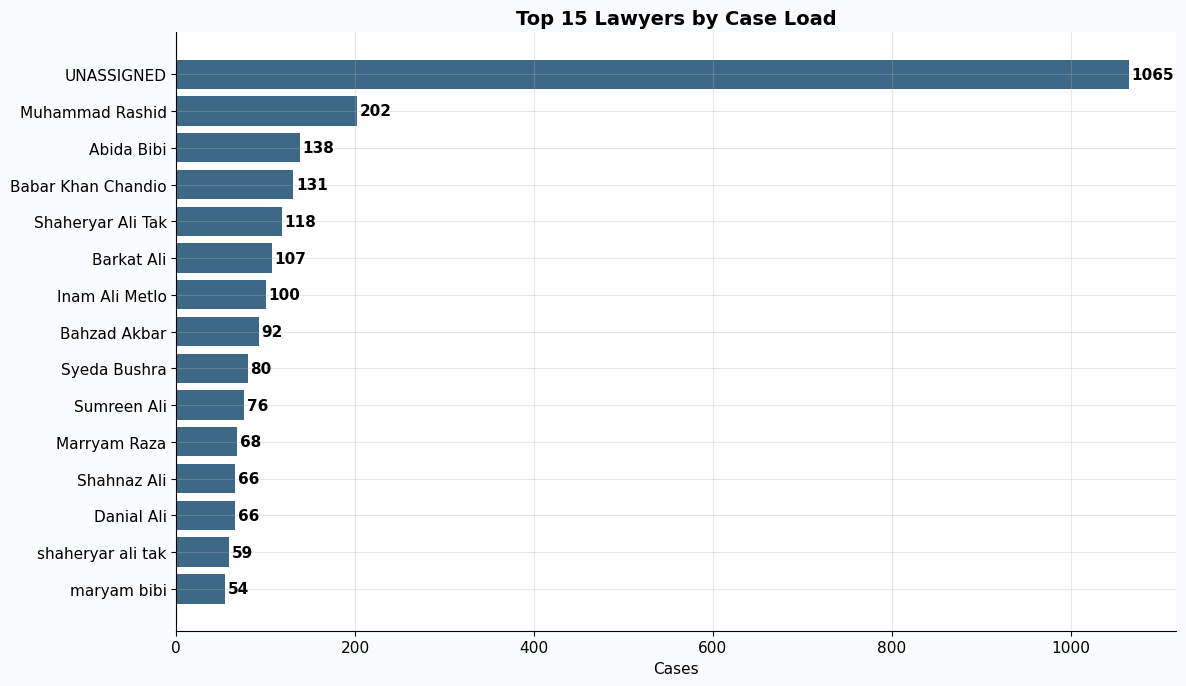

In [16]:
# In this DB, lawyer column is "lawyer1"
if 'lawyer1' in programs.columns:
    lc = programs['lawyer1'].fillna('UNASSIGNED').value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(lc.index[::-1], lc.values[::-1], color=COLORS['primary'], alpha=0.85)
    ax.set_xlabel('Cases'); ax.set_title('Top 15 Lawyers by Case Load')
    for b,v in zip(ax.patches, lc.values[::-1]):
        ax.text(b.get_width()+3, b.get_y()+b.get_height()/2, str(v), va='center', fontweight='bold')
    plt.tight_layout(); save_chart(fig, "lawyer_caseload"); plt.show()
else:
    print("⚠ lawyer1 not found")

### 4.2 Win Rates

  ✓ chart_12_win_rates.png


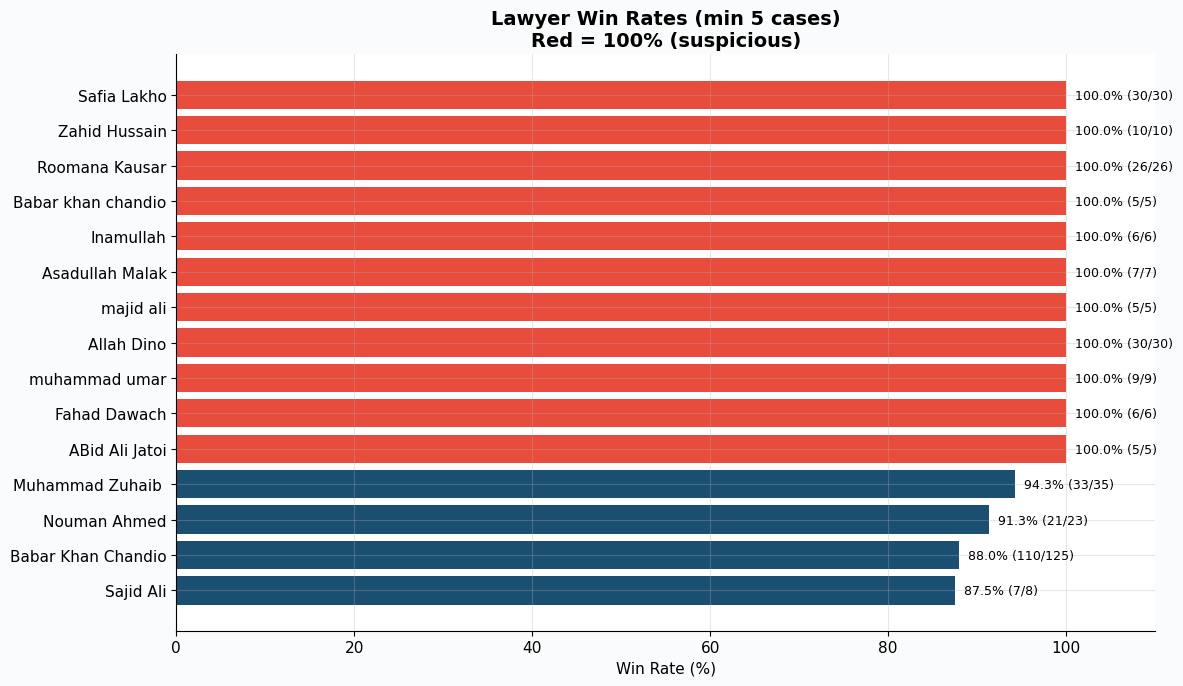

In [17]:
if 'lawyer1' in programs.columns and 'caseDecision' in programs.columns:
    dec = programs[programs['caseDecision'].notna()].copy()
    if not dec.empty:
        win_kw = ['favour','favor','won','success','granted']
        dec['_win'] = dec['caseDecision'].str.lower().apply(lambda x: any(k in str(x) for k in win_kw))
        st = dec.groupby('lawyer1').agg(n=('_win','count'), w=('_win','sum')).reset_index()
        st['rate'] = (st['w']/st['n']*100).round(1)
        act = st[st['n']>=5].sort_values('rate', ascending=False)
        
        fig, ax = plt.subplots(figsize=(12, 7))
        top = act.head(15).sort_values('rate')
        ax.barh(top['lawyer1'], top['rate'],
                color=[COLORS['warning'] if r==100 else COLORS['primary'] for r in top['rate']])
        ax.set_xlabel('Win Rate (%)'); ax.set_title('Lawyer Win Rates (min 5 cases)\nRed = 100% (suspicious)')
        ax.set_xlim(0, 110)
        for b,(_,r) in zip(ax.patches, top.iterrows()):
            ax.text(b.get_width()+1, b.get_y()+b.get_height()/2, f'{r["rate"]}% ({r["w"]}/{r["n"]})', va='center', fontsize=9)
        plt.tight_layout(); save_chart(fig, "win_rates"); plt.show()
        
        sus = len(act[act['rate']==100])
        if sus: add_finding("Lawyers", f"{sus} with 100% win rate", "MODERATE")
else:
    print("⚠ Need lawyer1 + caseDecision")

### 4.3 Court Level

  ✓ chart_13_court_levels.png


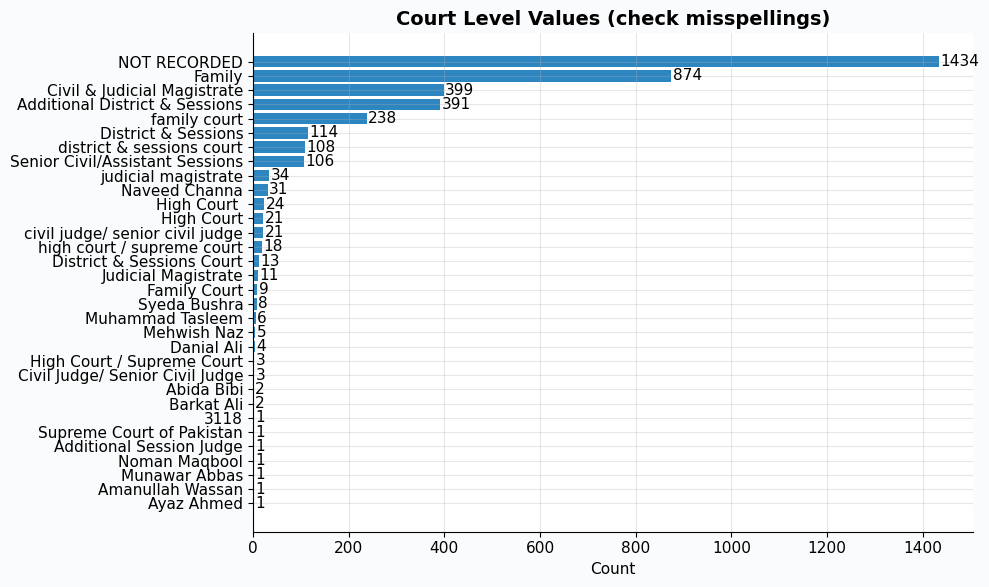

In [18]:
# In this DB, court level is "levelOfCourt"
if 'levelOfCourt' in programs.columns:
    cv = programs['levelOfCourt'].fillna('NOT RECORDED').value_counts()
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(cv.index[::-1], cv.values[::-1], color=COLORS['secondary'])
    ax.set_xlabel('Count'); ax.set_title('Court Level Values (check misspellings)')
    for b,v in zip(ax.patches, cv.values[::-1]):
        ax.text(b.get_width()+3, b.get_y()+b.get_height()/2, str(v), va='center')
    plt.tight_layout(); save_chart(fig, "court_levels"); plt.show()
    if len(cv)>7: add_finding("Courts", f"{len(cv)} variants — expected ~5", "CRITICAL")
else:
    print("⚠ levelOfCourt not found")

---
## Batch 5: Text & Duration

### 5.1 Case Facts Quality

  ✓ chart_14_casefacts.png


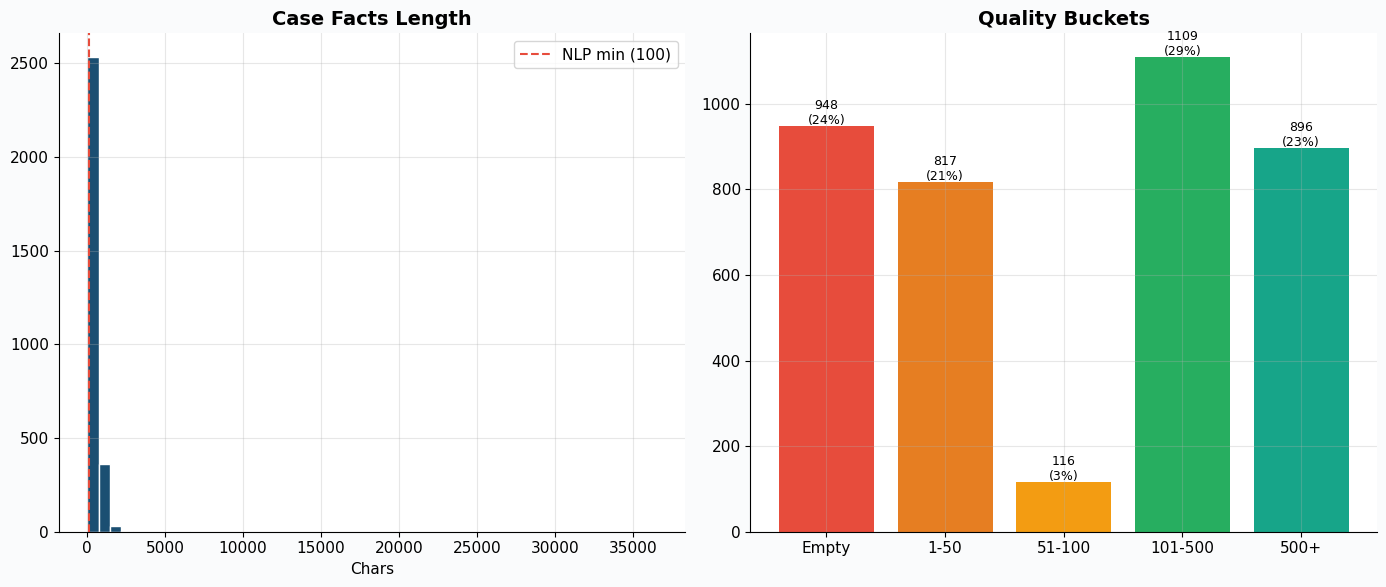

NLP-ready (>100 chars): 51.6%


In [19]:
if 'caseFacts' in programs.columns:
    fl = programs['caseFacts'].fillna('').astype(str).str.len()
    
    fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 6))
    ax1.hist(fl[fl>0], bins=50, color=COLORS['primary'], edgecolor='white')
    ax1.set_xlabel('Chars'); ax1.set_title('Case Facts Length')
    ax1.axvline(100, color=COLORS['warning'], linestyle='--', label='NLP min (100)')
    ax1.legend()
    
    bk = {'Empty':(fl==0).sum(), '1-50':((fl>0)&(fl<=50)).sum(), '51-100':((fl>50)&(fl<=100)).sum(),
          '101-500':((fl>100)&(fl<=500)).sum(), '500+':(fl>500).sum()}
    ax2.bar(bk.keys(), bk.values(), color=[COLORS['warning'],'#E67E22','#F39C12',COLORS['success'],COLORS['accent']])
    ax2.set_title('Quality Buckets')
    for i,(k,v) in enumerate(bk.items()):
        ax2.text(i, v+5, f'{v}\n({v/len(programs)*100:.0f}%)', ha='center', fontsize=9)
    plt.tight_layout(); save_chart(fig, "casefacts"); plt.show()
    
    nlp = (fl>100).sum()/len(programs)*100
    add_finding("Text", f"NLP-ready: {nlp:.1f}%", "CRITICAL" if nlp<50 else "INFO")
    print(f"NLP-ready (>100 chars): {nlp:.1f}%")
else:
    print("⚠ caseFacts not found")

### 5.2 Case Duration

  ✓ chart_15_duration.png


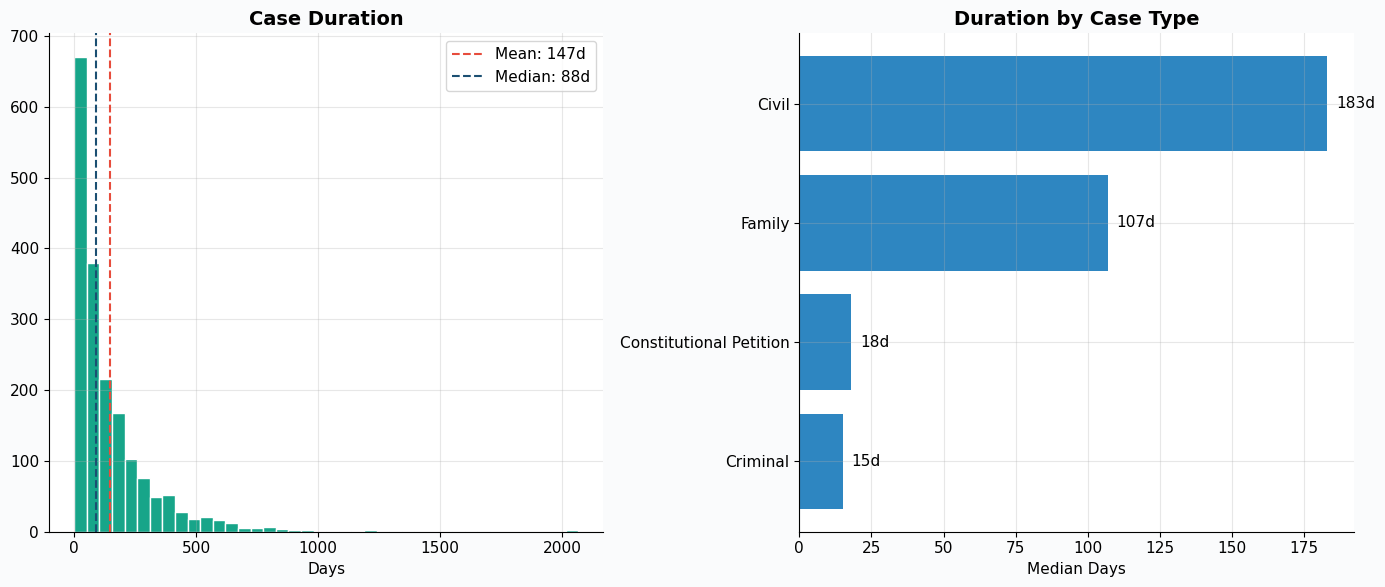

In [20]:
# In this DB: caseFileDate = filing, caseDisposalDate = disposal
fc = 'caseFileDate' if 'caseFileDate' in programs.columns else None
dc = 'caseDisposalDate' if 'caseDisposalDate' in programs.columns else None

if fc and dc:
    fdt = pd.to_datetime(programs[fc], errors='coerce')
    ddt = pd.to_datetime(programs[dc], errors='coerce')
    dur = (ddt - fdt).dt.days
    valid = dur[(dur>=0)&(dur<3650)].dropna()
    
    if len(valid) > 10:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        ax1.hist(valid, bins=40, color=COLORS['accent'], edgecolor='white')
        ax1.set_xlabel('Days'); ax1.set_title('Case Duration')
        ax1.axvline(valid.mean(), color=COLORS['warning'], linestyle='--', label=f'Mean: {valid.mean():.0f}d')
        ax1.axvline(valid.median(), color=COLORS['primary'], linestyle='--', label=f'Median: {valid.median():.0f}d')
        ax1.legend()
        
        if 'natureOfCase' in programs.columns:
            tmp = programs.copy(); tmp['_dur'] = dur
            tmp = tmp.dropna(subset=['_dur','natureOfCase'])
            tmp = tmp[(tmp['_dur']>=0)&(tmp['_dur']<3650)]
            top_t = tmp['natureOfCase'].value_counts().head(8).index
            med = tmp[tmp['natureOfCase'].isin(top_t)].groupby('natureOfCase')['_dur'].median().sort_values()
            ax2.barh(med.index, med.values, color=COLORS['secondary'])
            ax2.set_xlabel('Median Days'); ax2.set_title('Duration by Case Type')
            for b,v in zip(ax2.patches, med.values):
                ax2.text(b.get_width()+3, b.get_y()+b.get_height()/2, f'{v:.0f}d', va='center')
        plt.tight_layout(); save_chart(fig, "duration"); plt.show()
        
        bad = ((dur<0)|(dur>3650)).sum()
        if bad: add_finding("Dates", f"{bad} impossible dates", "CRITICAL")
        add_finding("Duration", f"Mean: {valid.mean():.0f}d, Median: {valid.median():.0f}d", "INFO")
    else:
        print(f"Only {len(valid)} valid durations")
else:
    print(f"⚠ Need caseFileDate ({fc}) + caseDisposalDate ({dc})")

### 5.3 Programs/Donors

  ✓ chart_16_programs.png


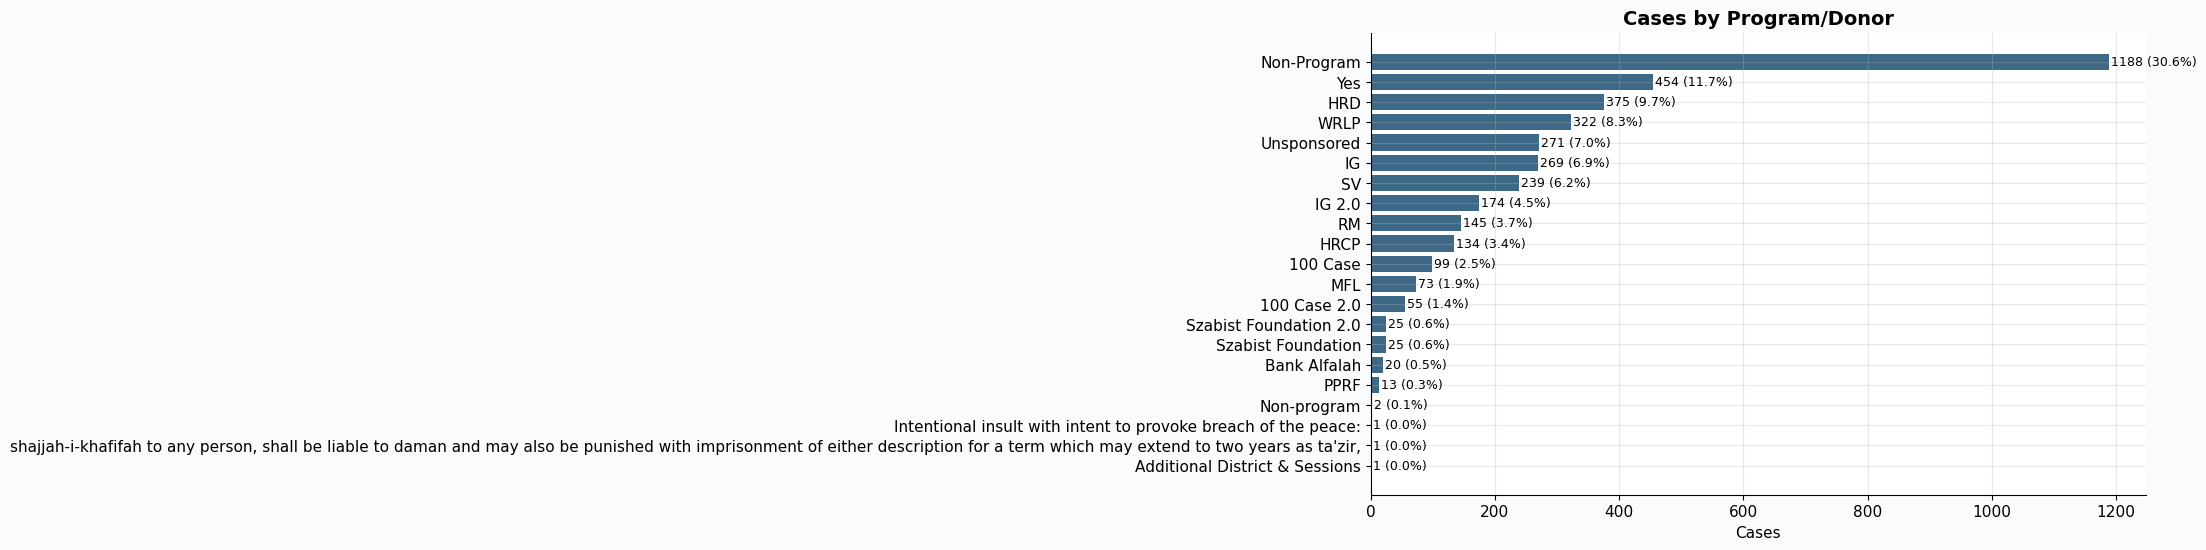

In [21]:
if 'programName' in programs.columns:
    pc = programs['programName'].fillna('Unsponsored').value_counts()
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(pc.index[::-1], pc.values[::-1], color=COLORS['primary'], alpha=0.85)
    ax.set_xlabel('Cases'); ax.set_title('Cases by Program/Donor')
    for b,v in zip(ax.patches, pc.values[::-1]):
        ax.text(b.get_width()+3, b.get_y()+b.get_height()/2, f'{v} ({v/len(programs)*100:.1f}%)', va='center', fontsize=9)
    plt.tight_layout(); save_chart(fig, "programs"); plt.show()

---
## Batch 6: PII Discovery

  [PERSON NAME    ] programs.interviewerName (3,612)
  [PERSON NAME    ] programs.clientName (3,165)
  [PERSON NAME    ] programs.partyName (328)
  [PERSON NAME    ] programs.complainantName (3,057)
  [PERSON NAME    ] programs.fatherHusbandName (3,553)
  [PHONE          ] programs.contactNumber (3,224)
  [PHONE          ] programs.alternativecontactNumber (1,290)
  [NATIONAL ID    ] programs.cnic (2,973)
  [AGE/DOB        ] programs.age (3,525)
  [AGE/DOB        ] programs.caseStage (2,395)
  [AGE/DOB        ] programs.caseStageother (118)
  [PERSON NAME    ] programs.username (2,698)
  [PERSON NAME    ] programs_detail.interviewerName (4,867)
  [PERSON NAME    ] programs_detail.clientName (4,860)
  [PERSON NAME    ] programs_detail.complainantName (3,486)
  [PERSON NAME    ] programs_detail.fatherHusbandName (5,682)
  [PHONE          ] programs_detail.contactNumber (5,023)
  [PHONE          ] programs_detail.alternativecontactNumber (1,559)
  [NATIONAL ID    ] programs_detail.cnic (3

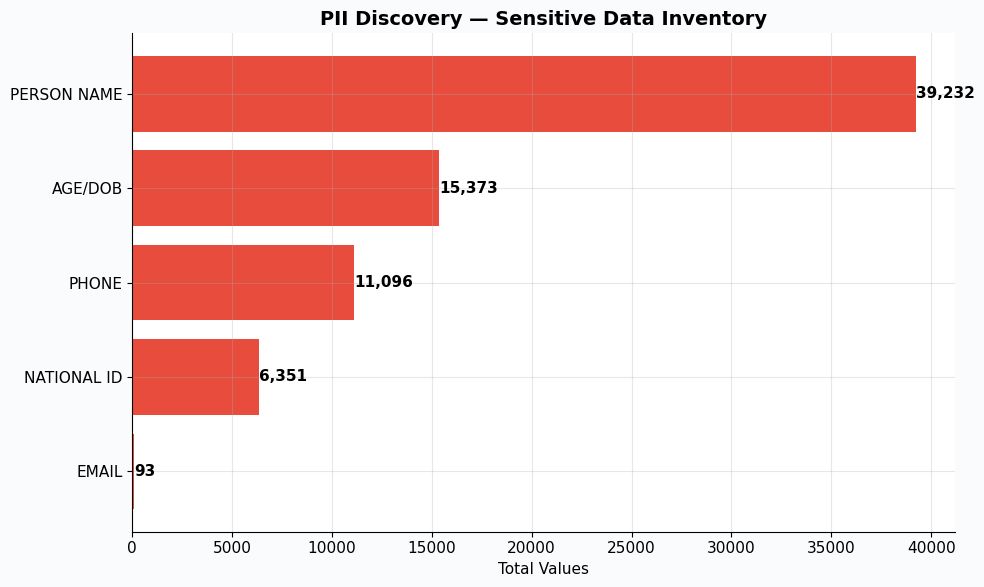

In [22]:
tables_scan = {'programs':programs, 'hearings':hearings, 'programs_detail':programs_detail, 'users':users}
pii_inv = []
for tn, df in tables_scan.items():
    if df.empty: continue
    for col in df.columns:
        cl = col.lower()
        pt = None
        if any(k in cl for k in ['clientname','fatherhusband','interviewername','complainant','partyname','username']): pt='PERSON NAME'
        elif any(k in cl for k in ['cnic']): pt='NATIONAL ID'
        elif any(k in cl for k in ['contactnumber','alternativecontact','mobile','phone']): pt='PHONE'
        elif 'address' in cl: pt='ADDRESS'
        elif 'email' in cl: pt='EMAIL'
        elif any(k in cl for k in ['age']): pt='AGE/DOB'
        if pt: pii_inv.append({'table':tn,'column':col,'pii_type':pt,'count':df[col].notna().sum()})

pii_df = pd.DataFrame(pii_inv)
if not pii_df.empty:
    for _,r in pii_df.iterrows():
        print(f"  [{r['pii_type']:15s}] {r['table']}.{r['column']} ({r['count']:,})")
    pii_df.to_csv(OUTPUT_DIR/"pii_inventory.csv", index=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ps = pii_df.groupby('pii_type')['count'].sum().sort_values(ascending=True)
    ax.barh(ps.index, ps.values, color=COLORS['warning'])
    ax.set_xlabel('Total Values'); ax.set_title('PII Discovery — Sensitive Data Inventory')
    for b,v in zip(ax.patches, ps.values):
        ax.text(b.get_width()+10, b.get_y()+b.get_height()/2, f'{v:,}', va='center', fontweight='bold')
    plt.tight_layout(); save_chart(fig, "pii"); plt.show()
    add_finding("PII", f"{len(pii_df)} PII columns, {pii_df['count'].sum():,} values", "CRITICAL")

---
## AI Readiness Score

  ✓ chart_18_ai_readiness.png


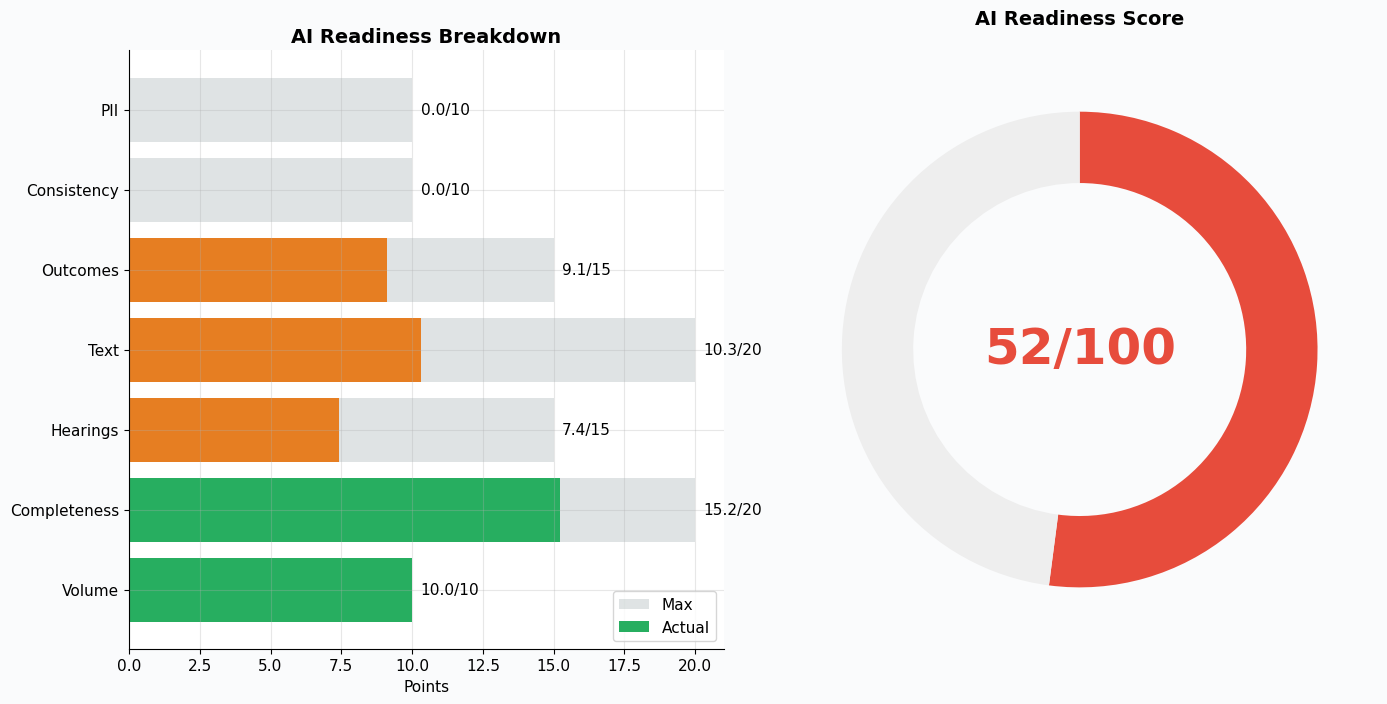


🎯 AI Readiness: 52/100


In [23]:
sc = {}
sc['Volume'] = min(10, len(programs)/500*10)
if completeness_data: sc['Completeness'] = np.mean([r['pct'] for r in completeness_data])/100*20
else: sc['Completeness'] = 0

if not hearings.empty and 'programsID' in hearings.columns:
    sc['Hearings'] = min(15, len(hearings['programsID'].unique())/len(programs)*15)
else: sc['Hearings'] = 0

sc['Text'] = ((programs['caseFacts'].fillna('').astype(str).str.len()>100).sum()/len(programs)*20) if 'caseFacts' in programs.columns else 0
sc['Outcomes'] = (programs['caseDecision'].notna().sum()/len(programs)*15) if 'caseDecision' in programs.columns else 0
sc['Consistency'] = max(0, 10 - sum(1 for f in findings if f['severity']=='CRITICAL')*2)
sc['PII'] = 0

total = sum(sc.values())

fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 7))
cats = list(sc.keys()); vals = list(sc.values())
maxs = [10,20,15,20,15,10,10]
ax1.barh(cats, maxs, color=COLORS['neutral'], alpha=0.3, label='Max')
ax1.barh(cats, vals, color=[COLORS['success'] if v/m>.7 else '#E67E22' if v/m>.4 else COLORS['warning'] for v,m in zip(vals,maxs)], label='Actual')
ax1.set_xlabel('Points'); ax1.set_title('AI Readiness Breakdown')
for i,(v,m) in enumerate(zip(vals,maxs)):
    ax1.text(m+0.3, i, f'{v:.1f}/{m}', va='center')
ax1.legend(loc='lower right')

clr = COLORS['success'] if total>=80 else '#E67E22' if total>=60 else COLORS['warning']
ax2.pie([total,100-total], colors=[clr,'#EEE'], startangle=90, counterclock=False, wedgeprops=dict(width=0.3))
ax2.text(0, 0, f'{total:.0f}/100', ha='center', va='center', fontsize=36, fontweight='bold', color=clr)
ax2.set_title('AI Readiness Score', pad=20)
plt.tight_layout(); save_chart(fig, "ai_readiness"); plt.show()
print(f"\n🎯 AI Readiness: {total:.0f}/100")

## Summary

In [ ]:
with open(OUTPUT_DIR/"findings.json",'w') as f:
    json.dump({'generated':datetime.now().isoformat(),'cases':len(programs),
        'score':round(total,1), 'components':{k:round(v,1) for k,v in sc.items()},
        'findings':findings, 'charts':chart_count}, f, indent=2)

print("="*60)
print("  PHASE 2 COMPLETE")
print("="*60)
print(f"  📊 Charts: {chart_count}")
print(f"  🎯 Score: {total:.0f}/100")
print(f"  📁 {OUTPUT_DIR.resolve()}")
for f in findings:
    icon = '🔴' if f['severity']=='CRITICAL' else '🟡' if f['severity']=='MODERATE' else '🟢'
    print(f"  {icon} [{f['category']}] {f['finding']}")

for c in [x for x in programs.columns if x.startswith('_')]:
    programs.drop(columns=[c], inplace=True, errors='ignore')
print("\n✅ Next: 02_pii_removal.ipynb")